# Introduction
## Brief description and motivation
Melting temeprature is an important equilibrium property of DNA melting, which captures the temperature at which the DNA duplex is half-open. It can also be thought of as the temperature at which the DNA tehermally denatures.\ 
Several experiments and modeling techniques rely on accurate predictions of the this melting temperature, particularly, of short DNA duplexes (<100 base pairs) in the presence of both monovalent (e.g., Sodium) and divalent (e.g., Magnesium) salt in the surrounding buffer.
One crucial example is Polymerase Chain Reaction (PCR) which simply involves amplifying small amounts of short DNA strands to obtain more samples that can then be used for a more detailed analysis such as in the detection of COVID-19.\
Typical PCR buffers involve both monovalent and divalent cations, and optimal amplification is achieved using annealing temperature that is **1-2 degrees** away from the melting temperature of the given duplex (Owc-2008 - see references below).\
Hence, it is crucial to predict melting temperatures as accurately as possible when designing PCR assays.

## Main datasets and models
We rely on an experimental dataset developed in Owc-2008. They combined prior melting experiments of DNA in monovalent dominant buffers with new results involving divalent dominant buffers as well as buffers with both types of cations.\
After their own data analysis, they developed a correction formula that predicts melting temperature to great accuracy for *Magnesium dominant conditions*
\begin{array}{r}
\frac{1}{T_{\mathrm{m}}\left(\mathrm{Mg}^{2+}\right)}=\frac{1}{T_{\mathrm{m}}\left(1 \mathrm{M} \mathrm{Na}^{+}\right)}+a+b \ln \left[\mathrm{Mg}^{2+}\right]+f_{\mathrm{GC}}(c+ 
\left.d \ln \left[\mathrm{Mg}^{2+}\right]\right)+\frac{1}{2\left(N_{\mathrm{bp}}-1\right)}\left[e+f \ln \left[\mathrm{Mg}^{2+}\right]+\right. 
\left.g\left(\ln \left[\mathrm{Mg}^{2+}\right]\right)^2\right],
\end{array}
where the left hand side is your target melting temperature at a given Magnesium concentration and the coefficients (a,b,c,d,e,f,g) on the right hand side were obtained using Linear Regression on a dataset of **680 melting temperature** with minimal monovalent salt present. They further corrected some coefficients (a,d,g) by making them monovalent salt dependent to improve predictions in buffers *when both cations* are present using a mixed dataset of **456 melting temperatures** (with 60 additional reference melting temperatures at monovalent dominant conditions).\
For *monovalent dominant conditions*, they similarly developed another formula in a prior study (Owc-2004)
\begin{array}{r}
\frac{1}{T_{\mathrm{m}}\left(\mathrm{Mon}^{+}\right)}= & \frac{1}{T_{\mathrm{m}}\left(1 \mathrm{M} \mathrm{Na}^{+}\right)}+\left(4.29 f_{\mathrm{GC}}-\right.
3.95) & \times 10^{-5} \ln \left[\mathrm{Mon}^{+}\right]+9.40 \times 10^{-6}\left(\ln \left[\mathrm{Mon}^{+}\right]\right)^2,
\end{array}
where a separate (divalent-independent) dataset of **580 melting temperatures** was used for this regression.\
Combining the different results, they developed a decision tree that can be used (Figure 9 in Owc-2008) to predict melting temperature at any given salt condition using one of the three developed formulas: 1) Monovalent only formula (Eq. 4 in Owc-2008), 2) Divalent only formula with fixed coefficients (Eq. 16 in Owc-2008), or 3) Divalent only formula with some monovalent-dependent coefficients (Eqs. 16 and 18-20).

**However, this approach is quite complicated as it involves: 0) more than one formula, 1) a decision tree of those formulas that relies on the ratio $R=\frac{\sqrt{Div^{+2}}}{Mono^+}$ which is not sufficiently motivated, 2) some parameters being salt dependent themselves with complex salt dependencies, 3) requiring the melting temperature at 1M Sodium that is obtained using the nearest-neighbor paramter [SantaLucia-1998] (yet another model) in general, 4) highly nonlinear dependencies on both [Mono] and [Div].**

## Other proposed models
A new set of experiments, Unz-2010 and Unz-2017, involving force-rupture of DNA hairpins showed quite similar prediction power of melting temperatures when compared to thermal melting results where they use nearest-neighbor parameters to predict the melting temperatures.\
Instead of having nonlinear salt dependencies, they suggested a linear-heterogenous method of calculating melting temperatures as a function of salt conditions that resolves some of the aforementioned complications.\
Relying on how melting temperature is obtainable from formation enthalpy ($\Delta H$) and entropy ($\Delta S$) of the given duplex (with total duplex concentration $C_t$ and $R$ being the gas constant)
\begin{array}{r}
\frac{1}{T_m}=\frac{\Delta S + R \ln(C_t/4)}{\Delta H},
\end{array}
they developed a nearest-neighbor set of parameters that have linear (in Log[Salt]) salt dependency **per parameter** with a dinucleotide dependent correction coefficient ($m_i$) instead of it being a global salt correction for the entire duplex
\begin{array}{r}
\Delta s_i =\Delta s_i^o - \frac{m_i}{T}\ln([Salt]),
\end{array}
where the total $\Delta S$ and $\Delta H$ are linear combinations of those individual parameters (i=index for one of the ten dinuclotides=AA/TT,AT/TA,CC/GG,...) depending on the duplex considered.

**However, they had to rely on melting temperature experiments to separately obtain the formation entropy and enthalpy per dinucleotide, and they were able to predict on either monvoalent dominant or divalent dominant salt conditions. A global formula using this approach was not obtainable to the best of my knowledge.**

## Our goal
Our goal in this project is two-fold:
1. We would like to acheieve high prediction accuracy (Low MAE) of melting temperature with mixed salt conditions using a limited number of data points (516 melting temperature - 12 Main sequences).
2. We *hope* to have a SINGLE global model that is simple/interpretable and captures the most biophysically relevant dependencies of the melting temperature (Low complexity and number of features).

For this notebook, we show prior trends of the melting temperature as a function of sequence (length and composition) as well as salt conditions (monovalent and divalent) to develop (in the Modeling notebook) an 1) accurate, 2) global, and hopefully 3) interpretable model of melting temperature of ANY short DNA at ANY given salt condition.\
**It is indeed a challenge to achieve all, accuracy-generality-interpretability, but let's see how far we can get!**

# Extra Notes on the dataset and the previously developed formulas - Owc-2008
General notes about the data used to develop the above formula:\
a. They used 680 melting temperature in Magnesium dominant environments - Table 1 of the main text and Table S1 in the supplementary information.\
b. They mainly considered 15/20/25/30bp sequences with variable GC content (the number of G and C in a given duplex strand) of 0.3/0.5/0.7, but they confirmed the accuracy of their formula on a set of 40bp and 60bp duplexes with other GC fractions.\
c. Different DNA concentrations were considered as well, but **I will be focusing on the majority case of 2 micro-molar**.\
d. Multi Linear Regression was performed on all 7 parameters after motivating the structure of this formula.\
e. Reduced Chi-squared, Bootstrap, SVD, and F-tests were used to estimate errors in the fitted parameters and confirm the significance/uniqueness of each and every parameter. **We will only focus on comparing MAE performance.**

There are couple of datasets to keep track of:\
a. Table 1 and Table S1: Magnesium dominant melting temperatures for 92 duplexes - Used for training of the above formula. (680 data points) - **We will not use this in here.**\
b. Table 4: Mix of Sodium and Magnesium concentrations for 12 duplexes - Used for training of the salt dependent coefficients formula. ***We will focus mainly on this one.*** (516 data points = 456 in mixed conditions and 60 in monovalent only ([Divalent]=0) conditions)\
c. Table S2: Validation data from different labs for 39 duplexes at a mix of salt conditions of both ions - These are not present in the training set and hence serve as a good test of our model as well! (69 data points - **it will be less when we use it since we only focus on one concentration, see below**)\
d. Owc-2004 data: Monovalent dominant melting temperatures - Used for training of the monvovalent correction formula shown above. **We will not use this in here.** (580 data points)\
The above formulas rely on the melting temperature at 1M Sodium as an input, so the data in (d) is essential in such analysis. However, they report the melting temperature at 1M when needed in Owc-2008, so we still won't have to touch that other paper.

**Note 1.1: One main disadvantage of prior models as we mentioned before is how they rely on the nearest-neighbor parameters [SantaLucia-1998] (developed at 1M Sodium) to obtain the melting temperature at 1M Sodium for cases that have not been obtained experimentally (which is EVERYTHING other than those sequences they covered). Those nearest-neghbor parameters themselves are obtained from fitting to other melting experiments, so they are yet another model used into that model.**
***Note 1.2: One major advantage of our model would be that it does not rely on the melting temperature at 1M Sodium as an input.***

## Conditions to keep in mind
1. Tris (another monovalent salt) of 2mM with 0.5-20mM Mg and 10mM with higher concentrations should be added to the total monovalent concentration - This was done on the divalent dominant dataset, *which we will not consider in here.*
2. Experimental error of 0.5 degrees is expected - **Achieving a prediction error of 1 degree is sufficient and perfect compared to other models (Table 5 in Owc-2008)!**
## Other things they checked
1. pH variation with temperature had minor (within 0.5 degree) impact on melting temperature - *Not considered for us anyway*.
2. Different monovalent ions (Sodium, Potassium, and Tris) stabilize the DNA duplexes similarly - Total monovalent ions concentration is the sum of individual contributions.
3. Monvalent models are less accurate in the presence of bulkier ions and large concentrations of ions capable of forming hydrogen bonds - *Not covered here as well*.

# Data Collection

One challenge is how all the data is available in tables in PDF format, no associated Excel/CSV files were given.\
The most reasonable approach to collect such data is to read those PDF files and then hope that the extracted tables are organized...

## Training set: Reading the dataset of the main text in Owc-2008 (Table 4)

Tried couple of ways to read the pdf file but it seems that the tables are not getting extracted properly.\
Tried OCR on images of the tables instead, but I keep running into a package issue with pytesseract even though everything seems properly installed.\
**To save time, I used Claude to extract this multi-page table.**

Visually confirmed couple of cases in the extracted data to ensure that they were properly extracted (If some of them are wrong, the resulting melting temperature will be quite off in the developed model and in the predictions using the above formulas - win-win :D).\
The dataset has 516 points=456 mixed conditions (non-zero monovalent and divalent) + 60 pure monovalent conditions.\
**Given the low number of data points, we will use the full 516 data points in model *training and validation.***\
A separate testing set is considered below.

In [45]:
import pandas as pd
owc2008_table4 = pd.read_csv('../datasets/owc2008_table4_all516.csv')
owc2008_table4.sample(10)

,duplex_id,sequence_5to3,length_bp,monovalent_mM,Mg2+_mM,Tm_C
184,ODN5,AGCTGCAGTGGATGTGAGAA,20,55,0.0,57.8
192,ODN5,AGCTGCAGTGGATGTGAGAA,20,105,0.0,62.4
132,ODN4,TGATTCTACCTATGTGATTT,20,1,10.0,57.7
118,ODN3,CAGCCTCGTCGCAGC,15,205,125.0,67.3
78,ODN2,GCAGTGGATGTGAGA,15,605,10.0,61.1
28,ODN1,TTCTACCTATGTGAT,15,205,0.0,47.7
39,ODN1,TTCTACCTATGTGAT,15,1005,1.5,53.0
261,ODN7,GTTCTATACTCTTGAAGTTGATTAC,25,1,10.0,62.4
474,ODN12,GACCTGACGTGGACCGCTCCTGGGCGTGGT,30,1,1.5,77.8
446,ODN11,AGTCTGGTCTGGATCTGAGAACTTCAGGCT,30,55,10.0,73.8


In [46]:
# Check that the length column is counting the number of characters in the sequence column properly
sum(owc2008_table4['length_bp'] == owc2008_table4['sequence_5to3'].apply(len)) # Good job Claude!

516

In [47]:
# Log[Salt] is typically used in the literature to show the relationship between salt concentration and melting temperature, so let's add a column for that
import numpy as np
owc2008_table4['log_monovalent_mM'] = np.log(owc2008_table4['monovalent_mM']*10**-3 + 1e-6)  # Convert mM to M before taking log and add a tiny number to avoid log(0)
owc2008_table4['log_Mg2+_mM'] = np.log(owc2008_table4['Mg2+_mM']*10**-3 + 1e-6)  # Convert mM to M before taking log and add a tiny number to avoid log(0)
owc2008_table4.sample(10)

,duplex_id,sequence_5to3,length_bp,monovalent_mM,Mg2+_mM,Tm_C,log_monovalent_mM,log_Mg2+_mM
491,ODN12,GACCTGACGTGGACCGCTCCTGGGCGTGGT,30,55,50.0,80.3,-2.900404,-2.995712
468,ODN11,AGTCTGGTCTGGATCTGAGAACTTCAGGCT,30,1005,0.0,80.1,0.004989,-13.815511
484,ODN12,GACCTGACGTGGACCGCTCCTGGGCGTGGT,30,5,125.0,79.8,-5.298117,-2.079434
247,ODN6,CAGCCTCGTTCGCACAGCCC,20,205,125.0,73.9,-1.584740,-2.079434
191,ODN5,AGCTGCAGTGGATGTGAGAA,20,55,125.0,67.5,-2.900404,-2.079434
149,ODN4,TGATTCTACCTATGTGATTT,20,105,0.0,51.9,-2.253785,-13.815511
275,ODN7,GTTCTATACTCTTGAAGTTGATTAC,25,55,20.0,63.0,-2.900404,-3.911973
86,ODN3,CAGCCTCGTCGCAGC,15,1,0.5,61.9,-6.906756,-7.598904
3,ODN1,TTCTACCTATGTGAT,15,1,10.0,50.2,-6.906756,-4.605070
174,ODN5,AGCTGCAGTGGATGTGAGAA,20,1,3.0,64.8,-6.906756,-5.808810


### Main EDA: Checking the trend between salt concentration and melting temperature for the 12 sequences

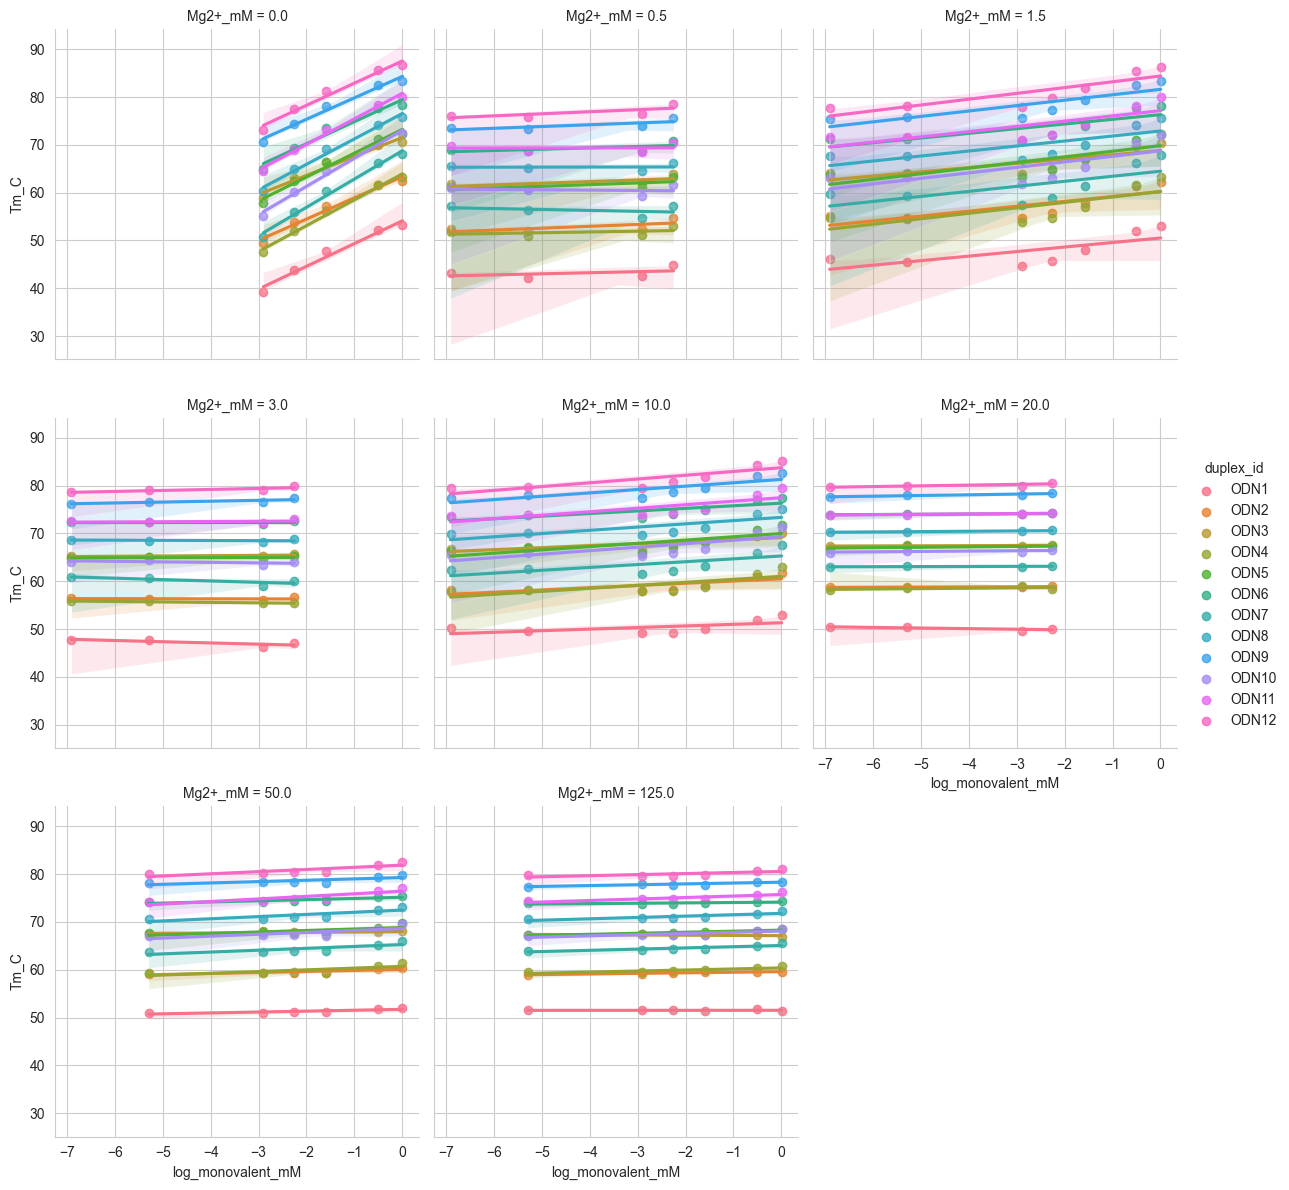

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
sns.lmplot(data=owc2008_table4, x='log_monovalent_mM', y='Tm_C', hue='duplex_id', 
           col='Mg2+_mM', col_wrap=3, height=4)

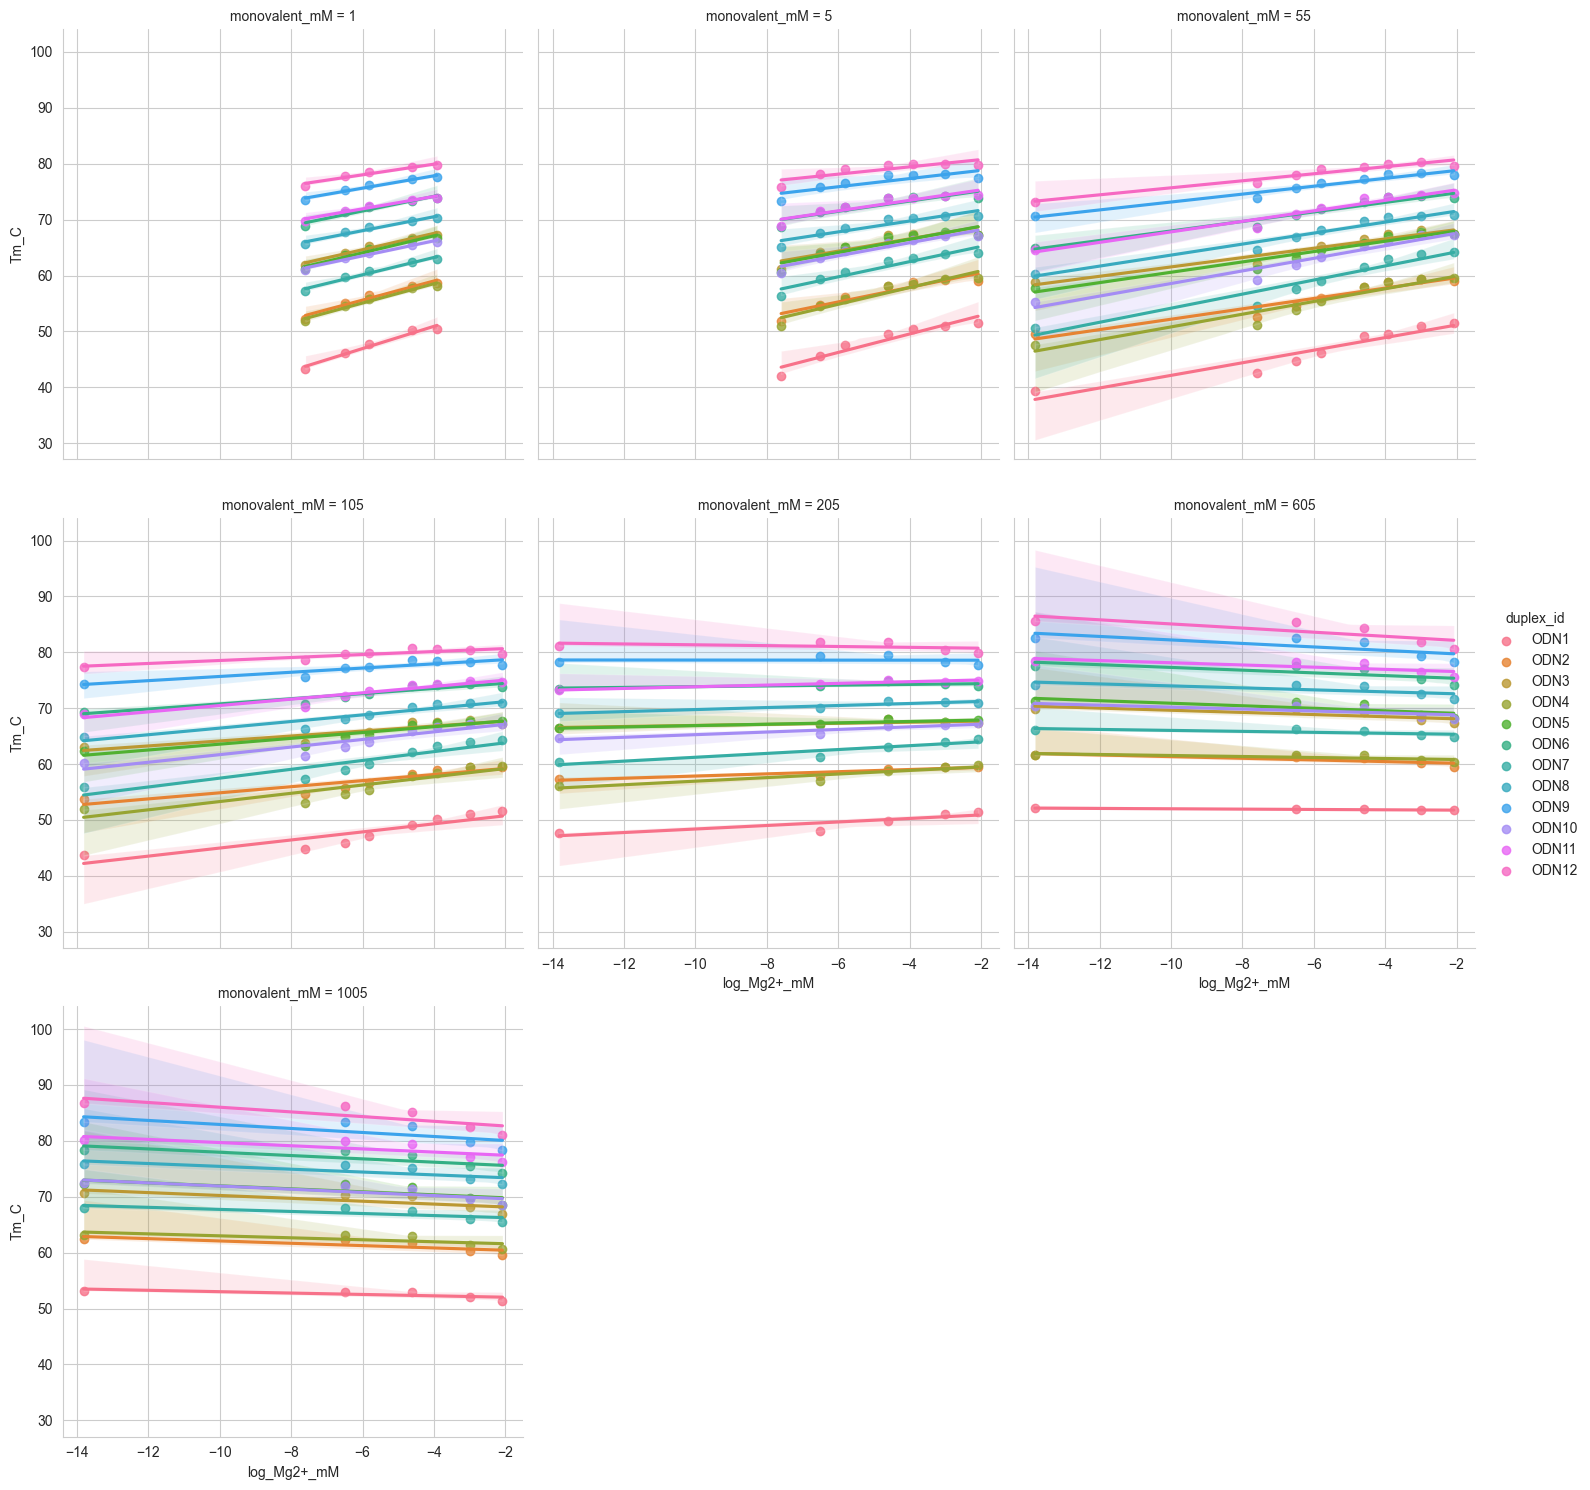

In [49]:
# Checking the trend between divalent salt concentration and melting temperature for the different sequences
# Making a grid for the different Monovalent concentrations with hue of duplex_id
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
sns.lmplot(data=owc2008_table4, x='log_Mg2+_mM', y='Tm_C', hue='duplex_id', col='monovalent_mM', col_wrap=3)

For low Magnesium (First row - first figure), there seems to be a linear relation between Log[Mono] and melting temeprature.\
For moderate Magnesium (Second row - first figure), the comptettion between the two cations starts to become clear, and nonlinear trends emerge. It also suggests that the slope of Tm vs. Log[Mono] is dependent on Magnesium, sort of the other side of the coin of what OWc-2008 did.\
For high Magnesium (Third row - first figure), things start to saturate and no further improvment is seen in the melting temperature, further validating the above observation.\
Looking at the other end (Melting temperature vs. Log[Magnesium]), the linear trend is clearer for the most part, but requires Log[Mono] dependent slopes (what Owc-2008 mainly developed).\
These observations are in line with what the paper reported, but we looked at it from a different angle for their new data that was not directly analyzed/visualized in the paper.

**This suggests a linear regression model with interaction terms or non-linear contributions as the paper did (Tm ~ a Log[Magnesium] + b Log[Magnesium]^2 with Log[Mono] dependent a and b coefficients), but we will attempt other approaches as well in the modeling notebook (e.g., Generalized Additive Model/Linear Regression with features engineering).**

### Other EDA: Melting temperature vs GC content, length, etc.

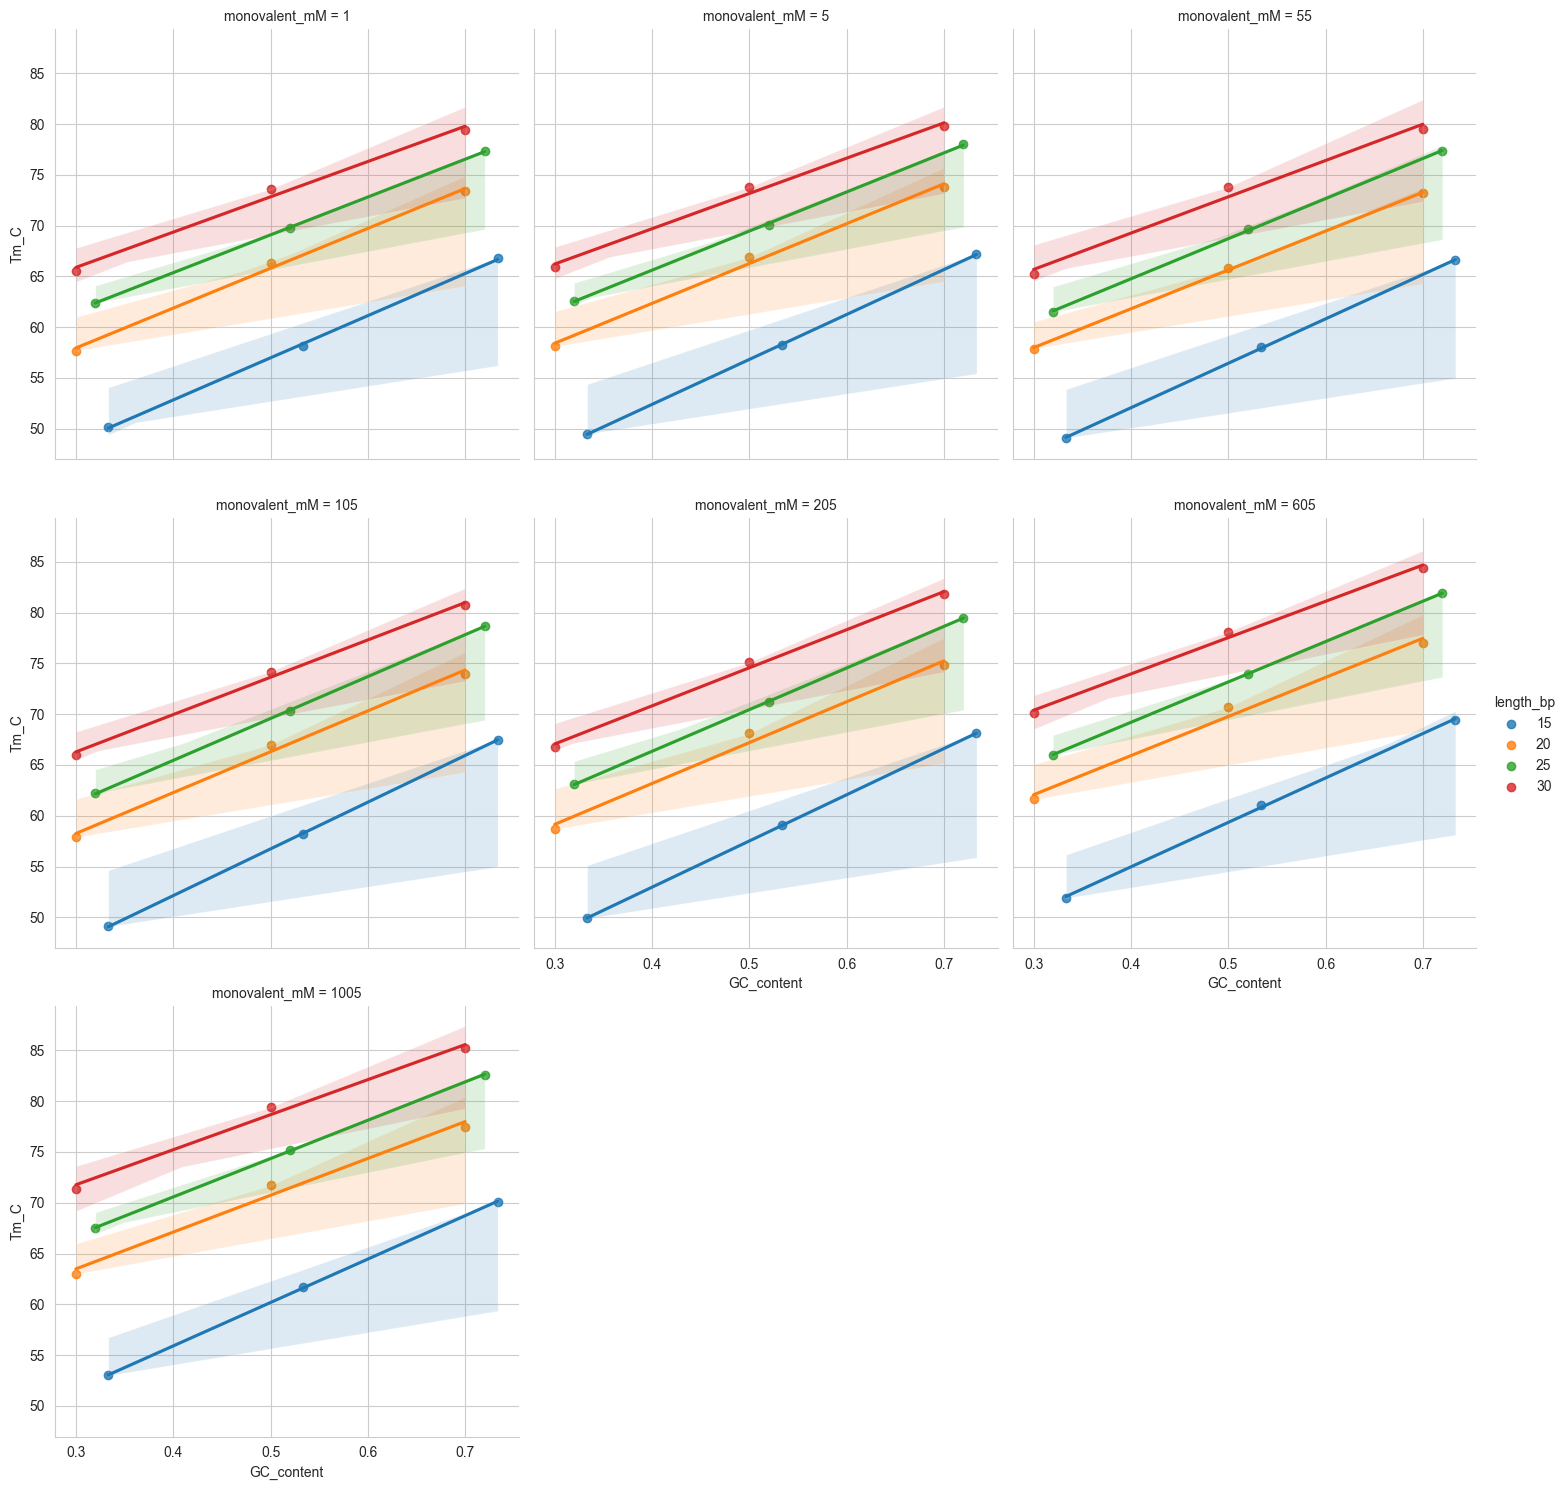

In [50]:
# Melting temperature vs. GC content - At a given Magnesium concentration for the different lengths and monovalent salt concentrations
owc2008_table4['GC_content'] = owc2008_table4['sequence_5to3'].apply(lambda seq: (seq.count('G') + seq.count('C')) / len(seq))
sns.lmplot(data=owc2008_table4[owc2008_table4['Mg2+_mM']==10], x='GC_content', y='Tm_C', hue='length_bp', col='monovalent_mM', col_wrap=3)

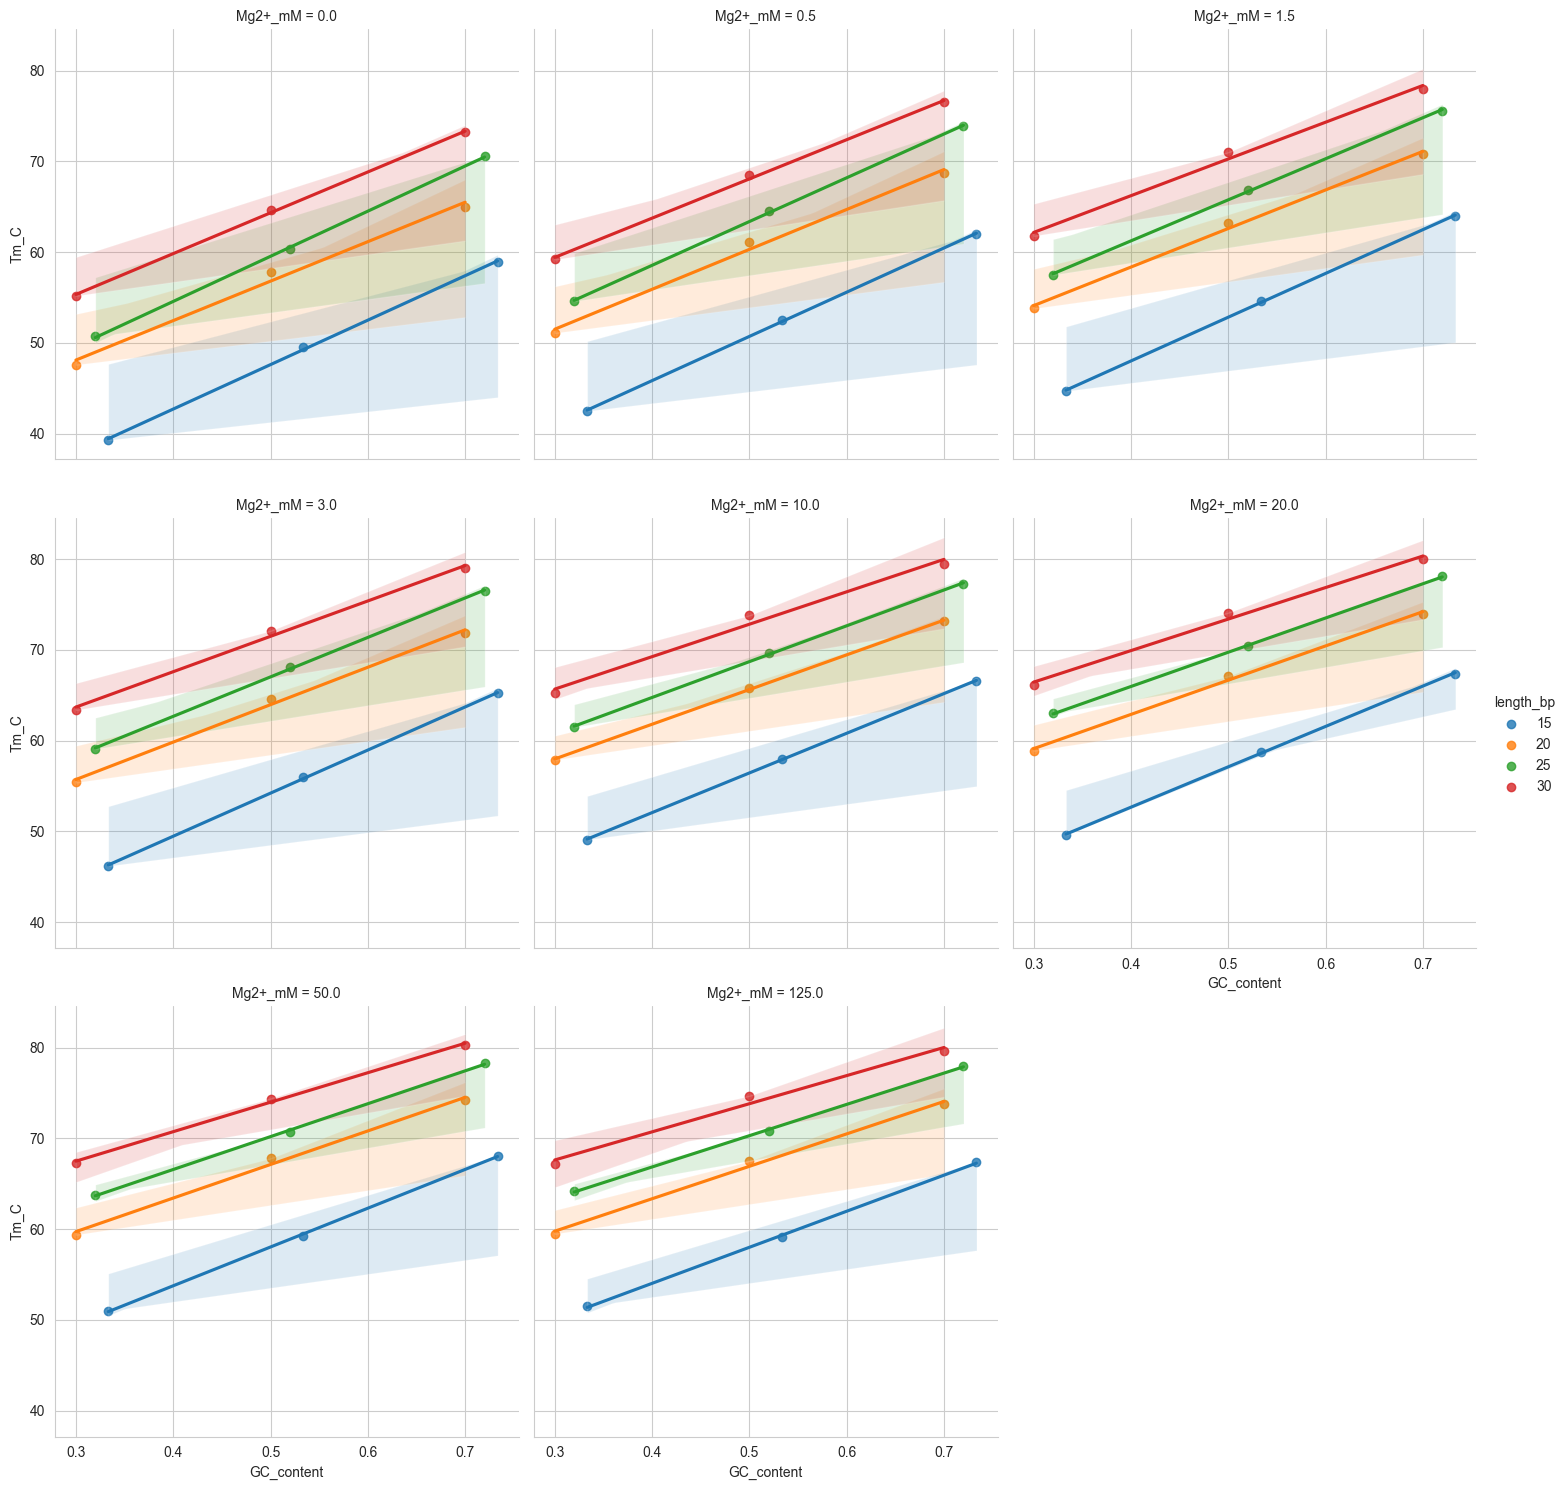

In [51]:
# Melting temperature vs. GC content - At a given Monovalent concentration for the different lengths and Magnesium salt concentrations
owc2008_table4['GC_content'] = owc2008_table4['sequence_5to3'].apply(lambda seq: (seq.count('G') + seq.count('C')) / len(seq))
sns.lmplot(data=owc2008_table4[owc2008_table4['monovalent_mM']==55], x='GC_content', y='Tm_C', hue='length_bp', col='Mg2+_mM', col_wrap=3)

Two main observations from these plots:
1. The higher the GC content, the higher the melting temperature as one would expect due to increased stabilization of duplexes with increased GC content.
2. For a given GC content, the melting temperature increase with salt condition in agreement with prior observations.

**This suggests that GC content will be an important feature to keep for our modeling as well as potential interactions with salt conditions, which was found to be true as well in the developed formula of that paper.**

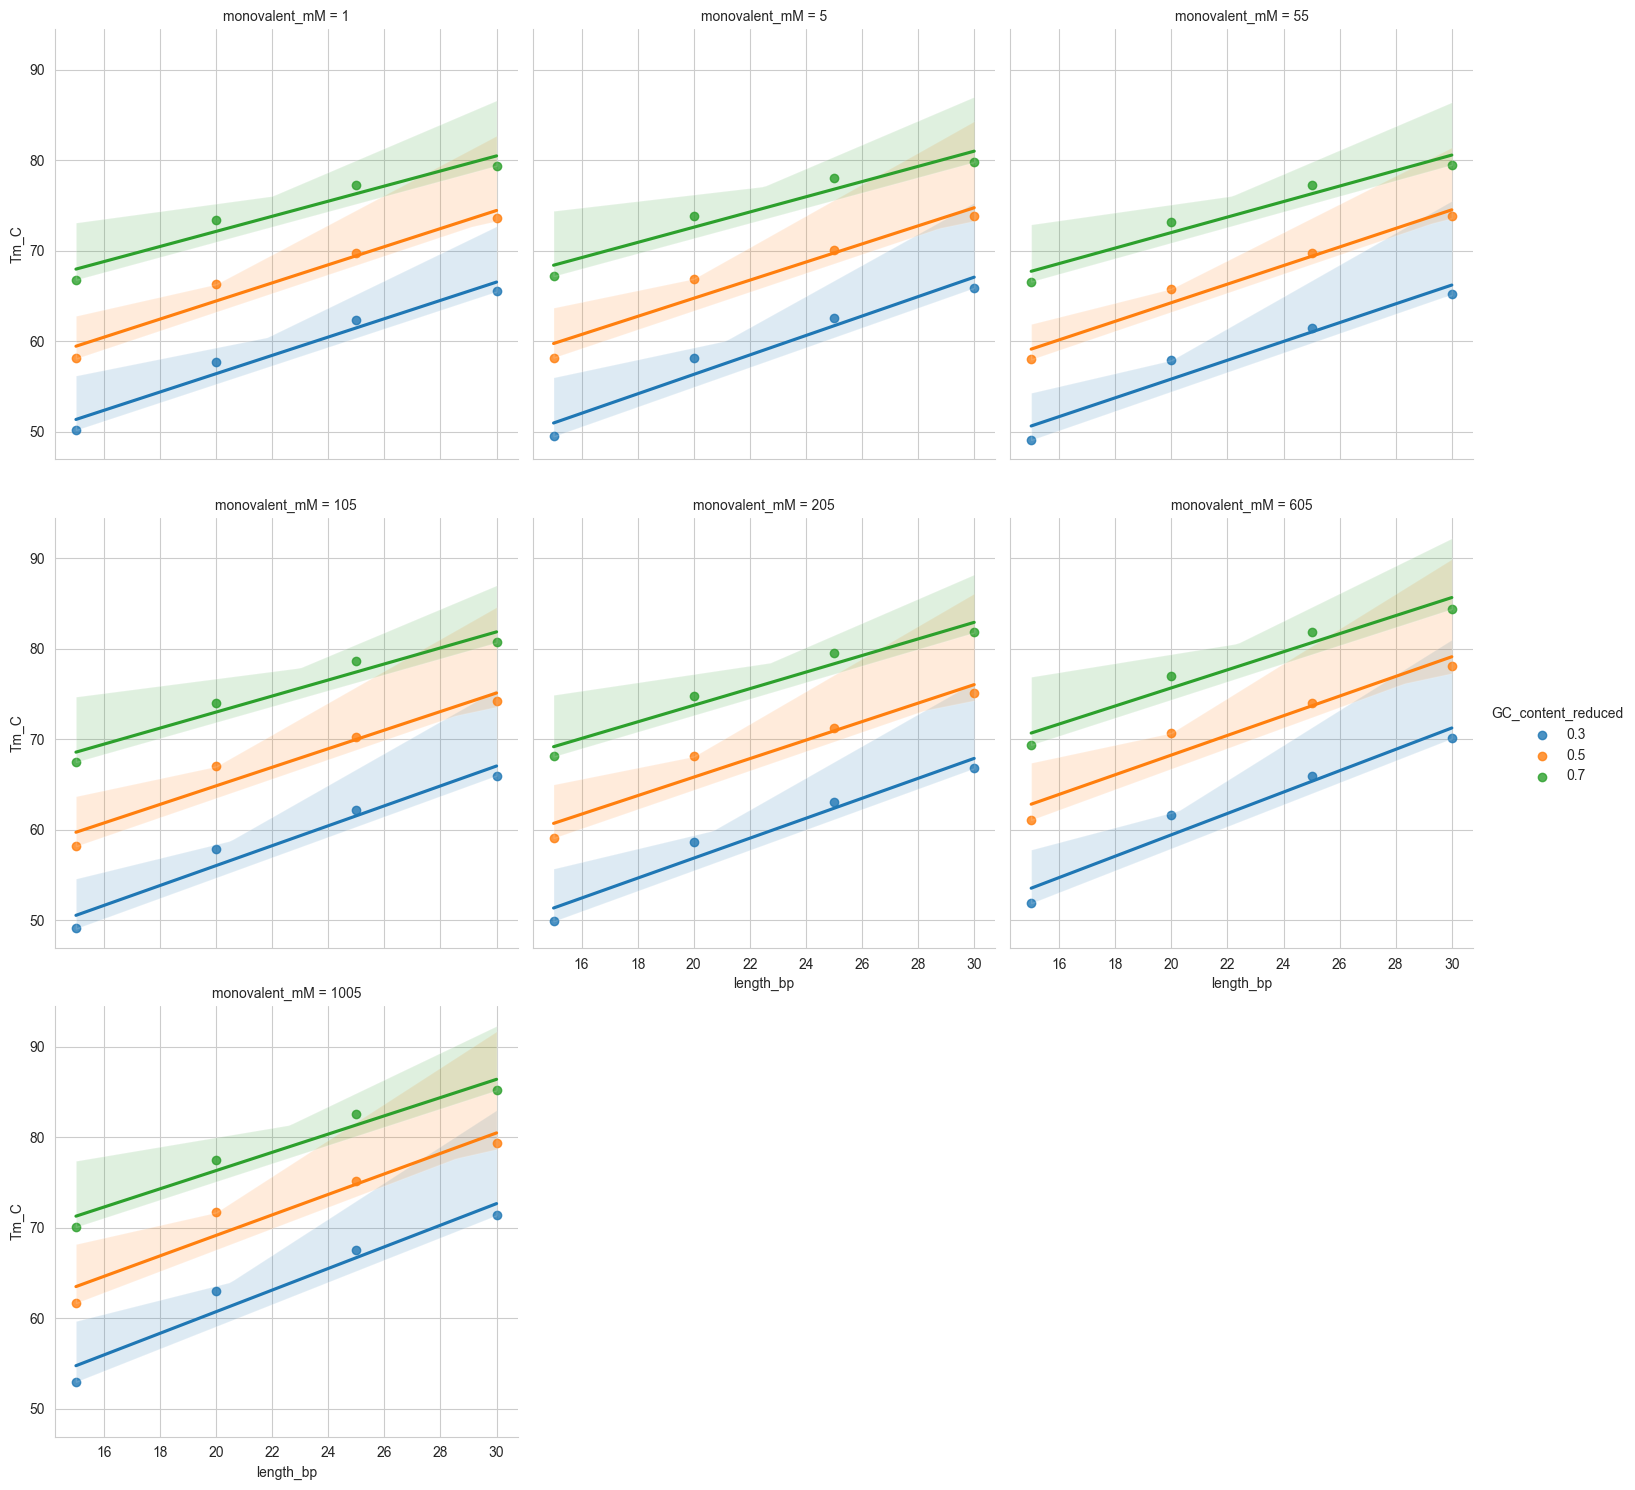

In [52]:
# Melting temperature vs. Length - At a given Magnesium concentration for the different GC content and monovalent salt concentrations
owc2008_table4['GC_content_reduced'] = owc2008_table4['GC_content'].apply(lambda seq: round(seq, 1))  # Round GC content to 1 decimal place for better visualization
sns.lmplot(data=owc2008_table4[owc2008_table4['Mg2+_mM']==10], x='length_bp', y='Tm_C', hue='GC_content_reduced', col='monovalent_mM', col_wrap=3)

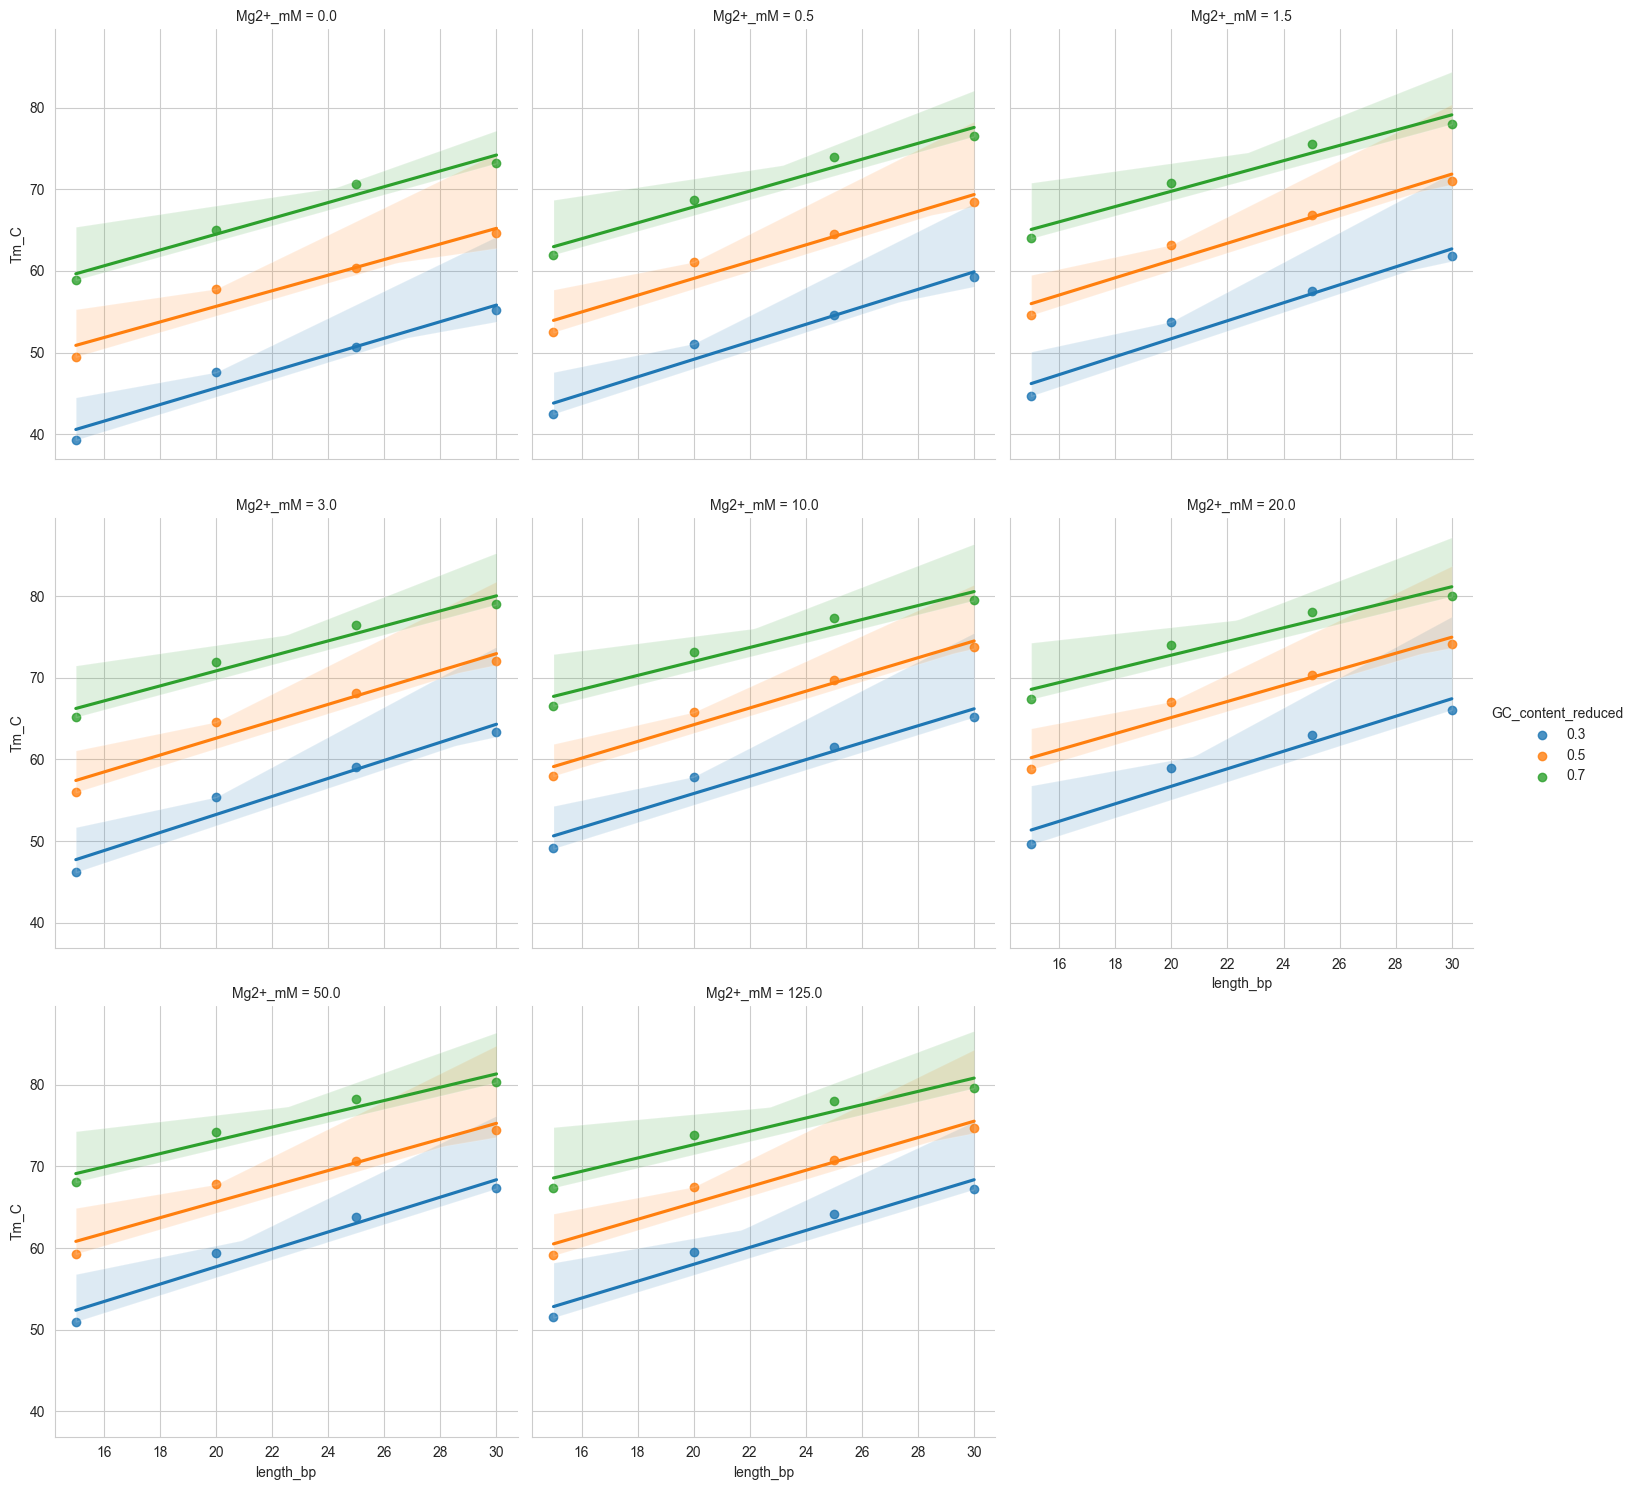

In [53]:
# Melting temperature vs. Length - At a given Monvalent concentration for the different GC content and Magnesium salt concentrations
owc2008_table4['GC_content_reduced'] = owc2008_table4['GC_content'].apply(lambda seq: round(seq, 1))  # Round GC content to 1 decimal place for better visualization
sns.lmplot(data=owc2008_table4[owc2008_table4['monovalent_mM']==55], x='length_bp', y='Tm_C', hue='GC_content_reduced', col='Mg2+_mM', col_wrap=3)

Two main observations from these plots as well:
1. The  longer the duplex, the higher the melting temperature as one would expect due to increased stabilization of duplexes with increased number of bases and associated bonding.
2. For a given length, the melting temperature increase with salt condition in agreement with prior observations.

**This also suggests that duplex length will be an important feature to keep for our modeling as well as potential interactions with salt conditions, which was found to be true as well in the developed formula of that paper.**

Other possible EDA can include the melting temperature dependence on the 1) fractions of nucleotide and dinucleotide steps, 2) salt interactions with other features and with \
Given literature trends, these are potential features that we need to consider in our modeling, **so we will compare different sets of features (features engineering) in the Modeling notebook.**

## Testing set: Reading the testing dataset from the supplementary material in Owc-2008 (Table S2)

To compare with the developed model in that paper, we will similarly use this as our testing set.\
However, some cleaning is needed as we particuarly need sequences that have:
1. Melting temperature at 1M Sodium, since the above formula requires this and we do not want to use the nearest-neighbor (i.e., yet another model) to estimate them.
2. Strand concentration of 2 micro-molar, since we do not deal with concentration effects at the moment.

This reduces the considered test set from 69 data points to 39 data points as shown below.

In [54]:
import pdfplumber
import pandas as pd
# Read the pdf file and extract all tables then combine them into a single dataframe
with pdfplumber.open('../datasets/Owc-2008-supp-TableS2.pdf') as pdf:
    tables = []
    for page in pdf.pages:
        tables.extend(page.extract_tables())
    owc2008_tabless2 = pd.concat([pd.DataFrame(table[1:], columns=table[0]) for table in tables], ignore_index=True)
owc2008_tabless2.head(10)

,Duplex DNA Sequence (5’ to 3’),C\nt\n(µM),N\nbp,Buffer 1,NaN,NaN,Buffer 2,NaN,NaN,NaN
0,NaN,NaN,NaN,[Mon+]\n(M),[Mg2+]\n(mM),Exp.\nT\nm\n(oC),[Mon+]\n(M),[Mg2+]\n(mM),Exp.\nT\nm\n(oC),T predicted\nm\nusing algorithm\nfrom Figure 9
1,GCCAGTTAA,8.0b,9,0.417,0.0,36.8,0.010,1.0,29.5,28.6
2,NaN,8.0b,9,0.417,0.0,36.8,0.010,10.0,35.4,38.3
3,NaN,8.0b,9,0.417,0.0,36.8,0.010,100.0,39.4,39.6
4,NaN,8.0b,9,0.417,0.0,36.8,0.110,1.0,32.0,32.5
5,NaN,8.0b,9,0.417,0.0,36.8,0.110,10.0,35.4,38.6
6,NaN,8.0b,9,0.417,0.0,36.8,0.110,100.0,38.6,39.6
7,AAAAAAAAAA,4.0c,10,1.0,0.0,30.0,0.005,50.0,32.4,30.5
8,GTAGATCACT,7.3d,10,0.515,0.0,43.0,0.010,50.0,45.7,44.7
9,NaN,7.3d,10,0.515,0.0,43.0,0.010,5.0,38.7,41.8


In [55]:
# Combining the first and second rows to create a single header row
# Rename the columns to be more descriptive and easier to work with
owc2008_tabless2.columns = ['sequence_5to3', 'Ct_micro', 'length_bp', 'monovalent1_M', 'Mg2+1_mM', 'Tm1_C', 'monovalent2_M', 'Mg2+2_mM', 'Tm2_C', 'T_pred_C']
# Remove the first row
owc2008_tabless2 = owc2008_tabless2.drop(0).reset_index(drop=True)
owc2008_tabless2.head(10)

,sequence_5to3,Ct_micro,length_bp,monovalent1_M,Mg2+1_mM,Tm1_C,monovalent2_M,Mg2+2_mM,Tm2_C,T_pred_C
0,GCCAGTTAA,8.0b,9,0.417,0.0,36.8,0.010,1.0,29.5,28.6
1,NaN,8.0b,9,0.417,0.0,36.8,0.010,10.0,35.4,38.3
2,NaN,8.0b,9,0.417,0.0,36.8,0.010,100.0,39.4,39.6
3,NaN,8.0b,9,0.417,0.0,36.8,0.110,1.0,32.0,32.5
4,NaN,8.0b,9,0.417,0.0,36.8,0.110,10.0,35.4,38.6
5,NaN,8.0b,9,0.417,0.0,36.8,0.110,100.0,38.6,39.6
6,AAAAAAAAAA,4.0c,10,1.0,0.0,30.0,0.005,50.0,32.4,30.5
7,GTAGATCACT,7.3d,10,0.515,0.0,43.0,0.010,50.0,45.7,44.7
8,NaN,7.3d,10,0.515,0.0,43.0,0.010,5.0,38.7,41.8
9,GGGGGAGGAGA,3.0e,11,0.155,0.0,50.0,0.155,10.0,54.5,54.2


In [56]:
# Keeping only the relevant colunms - drop prediction column and Magnesium concentration of the first buffer (0 for all)
owc2008_tabless2 = owc2008_tabless2.drop(columns=['Mg2+1_mM','T_pred_C'])
# Matching the column names of the last few columns to the first table for easier analysis later on
# Note: The monovalent concentrations are in Molar in this table, so we will convert them to mM for consistency with the first table (at the end)
owc2008_tabless2.columns = ['sequence_5to3', 'Ct_micro', 'length_bp', 'monovalent1_mM' , 'Tm1_C', 'monovalent_mM', 'Mg2+_mM', 'Tm_C']
owc2008_tabless2.head(10)

,sequence_5to3,Ct_micro,length_bp,monovalent1_mM,Tm1_C,monovalent_mM,Mg2+_mM,Tm_C
0,GCCAGTTAA,8.0b,9,0.417,36.8,0.010,1.0,29.5
1,NaN,8.0b,9,0.417,36.8,0.010,10.0,35.4
2,NaN,8.0b,9,0.417,36.8,0.010,100.0,39.4
3,NaN,8.0b,9,0.417,36.8,0.110,1.0,32.0
4,NaN,8.0b,9,0.417,36.8,0.110,10.0,35.4
5,NaN,8.0b,9,0.417,36.8,0.110,100.0,38.6
6,AAAAAAAAAA,4.0c,10,1.0,30.0,0.005,50.0,32.4
7,GTAGATCACT,7.3d,10,0.515,43.0,0.010,50.0,45.7
8,NaN,7.3d,10,0.515,43.0,0.010,5.0,38.7
9,GGGGGAGGAGA,3.0e,11,0.155,50.0,0.155,10.0,54.5


In [57]:
# Keeping only the cases with Ct_micro has 2.0 in its value (the index refer to the lab from which this was obtained which is not relevant) - focusing only on the cases with 2 microMolar concentration of the DNA duplexes
owc2008_tabless2 = owc2008_tabless2[owc2008_tabless2['Ct_micro'].str.contains('2.0', na=False)].reset_index(drop=True)
# Keeping only the cases where the melting temperature at 1M Sodium is given to supply for the model comparison later on.
owc2008_tabless2 = owc2008_tabless2[owc2008_tabless2['monovalent1_mM']=="1.0"].reset_index(drop=True)
owc2008_tabless2.head(10)

,sequence_5to3,Ct_micro,length_bp,monovalent1_mM,Tm1_C,monovalent_mM,Mg2+_mM,Tm_C
0,CTGACGACAAGACT,2.0a,14,1.0,60.5,0.055,1.5,51.8
1,NaN,2.0a,14,1.0,60.5,0.005,10.0,56.3
2,GTAACCGGCATGAA,2.0a,14,1.0,60.8,0.055,20.0,57.0
3,NaN,2.0a,14,1.0,60.8,0.005,20.0,57.0
4,CGCTGCTCACCTGA,2.0a,14,1.0,66.1,0.055,3.0,59.6
5,NaN,2.0a,14,1.0,66.1,0.205,125.0,62.0
6,TCTCAATGGTGTTACG,2.0a,16,1.0,60.4,0.055,1.5,51.8
7,NaN,2.0a,16,1.0,60.4,0.005,0.5,49.0
8,TCTCAAACACCACACG,2.0a,16,1.0,64.4,0.055,3.0,57.7
9,NaN,2.0a,16,1.0,64.4,0.205,10.0,60.0


In [58]:
# Replace NaN values in the sequence_5to3 column with the previous non-NaN value (A single sequence is repeated for multiple rows with different salt concentrations and melting temperatures, so we can fill the missing values with the previous value in the column)
owc2008_tabless2['sequence_5to3'] = owc2008_tabless2['sequence_5to3'].ffill()
owc2008_tabless2.head(10)

,sequence_5to3,Ct_micro,length_bp,monovalent1_mM,Tm1_C,monovalent_mM,Mg2+_mM,Tm_C
0,CTGACGACAAGACT,2.0a,14,1.0,60.5,0.055,1.5,51.8
1,CTGACGACAAGACT,2.0a,14,1.0,60.5,0.005,10.0,56.3
2,GTAACCGGCATGAA,2.0a,14,1.0,60.8,0.055,20.0,57.0
3,GTAACCGGCATGAA,2.0a,14,1.0,60.8,0.005,20.0,57.0
4,CGCTGCTCACCTGA,2.0a,14,1.0,66.1,0.055,3.0,59.6
5,CGCTGCTCACCTGA,2.0a,14,1.0,66.1,0.205,125.0,62.0
6,TCTCAATGGTGTTACG,2.0a,16,1.0,60.4,0.055,1.5,51.8
7,TCTCAATGGTGTTACG,2.0a,16,1.0,60.4,0.005,0.5,49.0
8,TCTCAAACACCACACG,2.0a,16,1.0,64.4,0.055,3.0,57.7
9,TCTCAAACACCACACG,2.0a,16,1.0,64.4,0.205,10.0,60.0


In [59]:
# Remove \n characters from the sequences in the sequence column
owc2008_tabless2['sequence_5to3'] = owc2008_tabless2['sequence_5to3'].str.replace('\n', '', regex=False)
owc2008_tabless2.head(10)

,sequence_5to3,Ct_micro,length_bp,monovalent1_mM,Tm1_C,monovalent_mM,Mg2+_mM,Tm_C
0,CTGACGACAAGACT,2.0a,14,1.0,60.5,0.055,1.5,51.8
1,CTGACGACAAGACT,2.0a,14,1.0,60.5,0.005,10.0,56.3
2,GTAACCGGCATGAA,2.0a,14,1.0,60.8,0.055,20.0,57.0
3,GTAACCGGCATGAA,2.0a,14,1.0,60.8,0.005,20.0,57.0
4,CGCTGCTCACCTGA,2.0a,14,1.0,66.1,0.055,3.0,59.6
5,CGCTGCTCACCTGA,2.0a,14,1.0,66.1,0.205,125.0,62.0
6,TCTCAATGGTGTTACG,2.0a,16,1.0,60.4,0.055,1.5,51.8
7,TCTCAATGGTGTTACG,2.0a,16,1.0,60.4,0.005,0.5,49.0
8,TCTCAAACACCACACG,2.0a,16,1.0,64.4,0.055,3.0,57.7
9,TCTCAAACACCACACG,2.0a,16,1.0,64.4,0.205,10.0,60.0


In [60]:
# Making sure all the numbers are in the right format for later use
owc2008_tabless2['length_bp'] = owc2008_tabless2['length_bp'].astype(int)
owc2008_tabless2['monovalent1_mM'] = owc2008_tabless2['monovalent1_mM'].astype(float) * 1000  # Convert from M to mM
owc2008_tabless2['monovalent_mM'] = owc2008_tabless2['monovalent_mM'].astype(float) * 1000  # Convert from M to mM
owc2008_tabless2['Mg2+_mM'] = owc2008_tabless2['Mg2+_mM'].astype(float)
owc2008_tabless2['Tm1_C'] = owc2008_tabless2['Tm1_C'].astype(float)
owc2008_tabless2['Tm_C'] = owc2008_tabless2['Tm_C'].astype(float)
owc2008_tabless2

,sequence_5to3,Ct_micro,length_bp,monovalent1_mM,Tm1_C,monovalent_mM,Mg2+_mM,Tm_C
0,CTGACGACAAGACT,2.0a,14,1000.0,60.5,55.0,1.5,51.8
1,CTGACGACAAGACT,2.0a,14,1000.0,60.5,5.0,10.0,56.3
2,GTAACCGGCATGAA,2.0a,14,1000.0,60.8,55.0,20.0,57.0
3,GTAACCGGCATGAA,2.0a,14,1000.0,60.8,5.0,20.0,57.0
4,CGCTGCTCACCTGA,2.0a,14,1000.0,66.1,55.0,3.0,59.6
5,CGCTGCTCACCTGA,2.0a,14,1000.0,66.1,205.0,125.0,62.0
6,TCTCAATGGTGTTACG,2.0a,16,1000.0,60.4,55.0,1.5,51.8
7,TCTCAATGGTGTTACG,2.0a,16,1000.0,60.4,5.0,0.5,49.0
8,TCTCAAACACCACACG,2.0a,16,1000.0,64.4,55.0,3.0,57.7
9,TCTCAAACACCACACG,2.0a,16,1000.0,64.4,205.0,10.0,60.0


In [61]:
# # Save the cleaned table to a new CSV file for later use. Skip the Ct_micro and monovalent1_mM columns
# owc2008_tabless2.drop(columns=['Ct_micro', 'monovalent1_mM']).to_csv('datasets/owc2008_tableS2_cleaned.csv', index=False)

## Final considerations
We compare the different distributions of features in the test set and training set to keep track of uncaptures trends within the training set.

In [62]:
# Confirm sequence independence between test set and training set
sequences_in_S2 = set(owc2008_tabless2['sequence_5to3'].unique())
sequences_in_training = set(owc2008_table4['sequence_5to3'].unique())
intersection = sequences_in_S2.intersection(sequences_in_training)
print(f"Number of sequences in test set: {len(sequences_in_S2)}")
print(f"Number of sequences in training data: {len(sequences_in_training)}")
print(f"Number of sequences in both test set and training data: {len(intersection)}")

Number of sequences in test set: 19
Number of sequences in training data: 12
Number of sequences in both test set and training data: 0


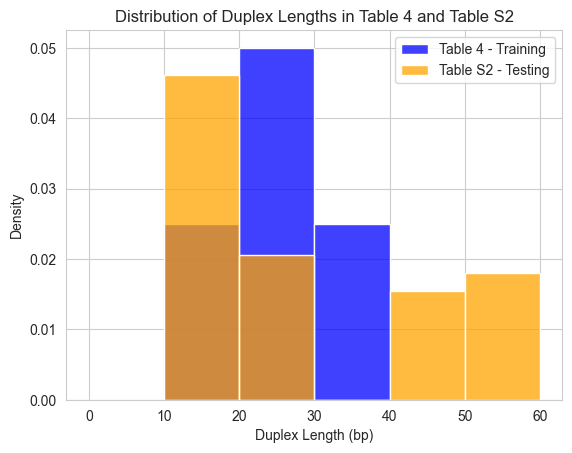

In [67]:
# Compare the duplex lengths and GC content between the two tables to see if they are similar or different
bins_length = [0, 10, 20, 30, 40, 50, 60]
owc2008_table4['GC_content'] = owc2008_table4['sequence_5to3'].apply(lambda seq: (seq.count('G') + seq.count('C')) / len(seq))
owc2008_tabless2['GC_content'] = owc2008_tabless2['sequence_5to3'].apply(lambda seq: (seq.count('G') + seq.count('C')) / len(seq))
sns.histplot(owc2008_table4['length_bp'], bins=bins_length, color='blue', label='Table 4 - Training', stat='density')
sns.histplot(owc2008_tabless2['length_bp'], bins=bins_length, color='orange', label='Table S2 - Testing', stat='density')
plt.title('Distribution of Duplex Lengths in Table 4 and Table S2')
plt.xlabel('Duplex Length (bp)')
plt.legend()

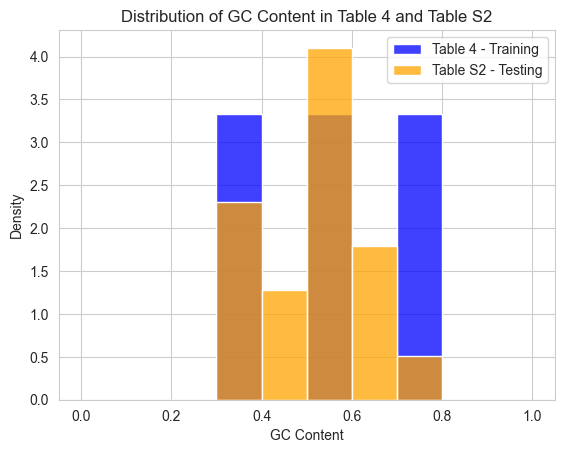

In [68]:
bins_gc = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
sns.histplot(owc2008_table4['GC_content'], bins=bins_gc, color='blue', label='Table 4 - Training', stat='density')
sns.histplot(owc2008_tabless2['GC_content'], bins=bins_gc, color='orange', label='Table S2 - Testing', stat='density')
plt.title('Distribution of GC Content in Table 4 and Table S2')
plt.xlabel('GC Content')
plt.legend()

**For the length distribution:** There are some samples (~19 cases of 40bp+60bp) with lengths outside the range of the triaining data which might through off our testing results.\
**For the GC-content distribution:** The test set lies in between the max_GC and min_GC found in the training set, so there shouldn't be an issue with that.


# References:
1. SantaLucia-1998: J. SantaLucia, A unified view of polymer, dumbbell, and oligonucleotide DNA nearest-neighbor thermodynamics, Proc. Natl. Acad. Sci. U.S.A. 95 (4) 1460-1465, https://doi.org/10.1073/pnas.95.4.1460 (1998).
2. Owc-2004: Effects of Sodium Ions on DNA Duplex Oligomers:  Improved Predictions of Melting Temperatures
Richard Owczarzy, Yong You, Bernardo G. Moreira, Jeffrey A. Manthey, Lingyan Huang, Mark A. Behlke, and Joseph A. Walder
Biochemistry 2004 43 (12), 3537-3554
DOI: https://doi.org/10.1021/bi034621r
3. Owc-2008: Predicting Stability of DNA Duplexes in Solutions Containing Magnesium and Monovalent Cations
Richard Owczarzy, Bernardo G. Moreira, Yong You, Mark A. Behlke, and Joseph A. Walder
Biochemistry 2008 47 (19), 5336-5353
DOI: https://doi.org/10.1021/bi702363u
4. Unz-2010: J.M. Huguet, C.V. Bizarro, N. Forns, S.B. Smith, C. Bustamante, & F. Ritort, Single-molecule derivation of salt dependent base-pair free energies in DNA, Proc. Natl. Acad. Sci. U.S.A. 107 (35) 15431-15436, https://doi.org/10.1073/pnas.1001454107 (2010).
5. Unz-2017: Josep Maria Huguet, Marco Ribezzi-Crivellari, Cristiano Valim Bizarro, Felix Ritort, Derivation of nearest-neighbor DNA parameters in magnesium from single molecule experiments, Nucleic Acids Research, Volume 45, Issue 22, 15 December 2017, Pages 12921–12931, https://doi.org/10.1093/nar/gkx1161
